In [1]:
import os
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Define and create the state folder
DRIVE_PATH = '/content/drive/MyDrive/advance_ml_project'
REGULARIZED_MODEL = DRIVE_PATH + '/tuned_with_regularization'
NON_REGULARIZED_MODEL = DRIVE_PATH + '/tuned_without_regularization'

assert(os.path.exists(DRIVE_PATH))
assert(os.path.exists(REGULARIZED_MODEL))
assert(os.path.exists(NON_REGULARIZED_MODEL))

BASE_MODEL = 'TechWolf/JobBERT-v2'

Mounted at /content/drive


In [ ]:
!pip install sentence-transformers torch scikit-learn

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

2_Asym/140216480444672_Dense/model.safet(…):   0%|          | 0.00/3.15M [00:00<?, ?B/s]

2_Asym/140216480445248_Dense/model.safet(…):   0%|          | 0.00/3.15M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:01<?, ?it/s]

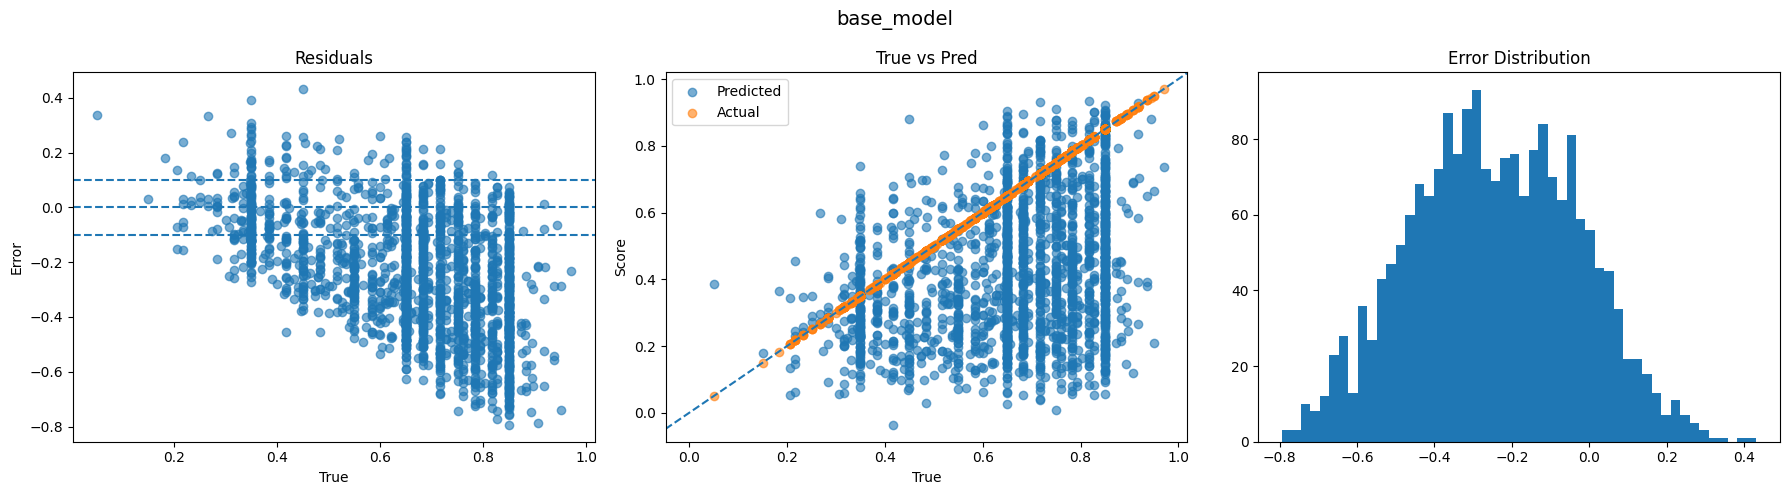


base_model
MAE: 0.2707
RMSE: 0.3262
Pearson: 0.2976
Spearman: 0.2811
Accuracy (%): 22.4000


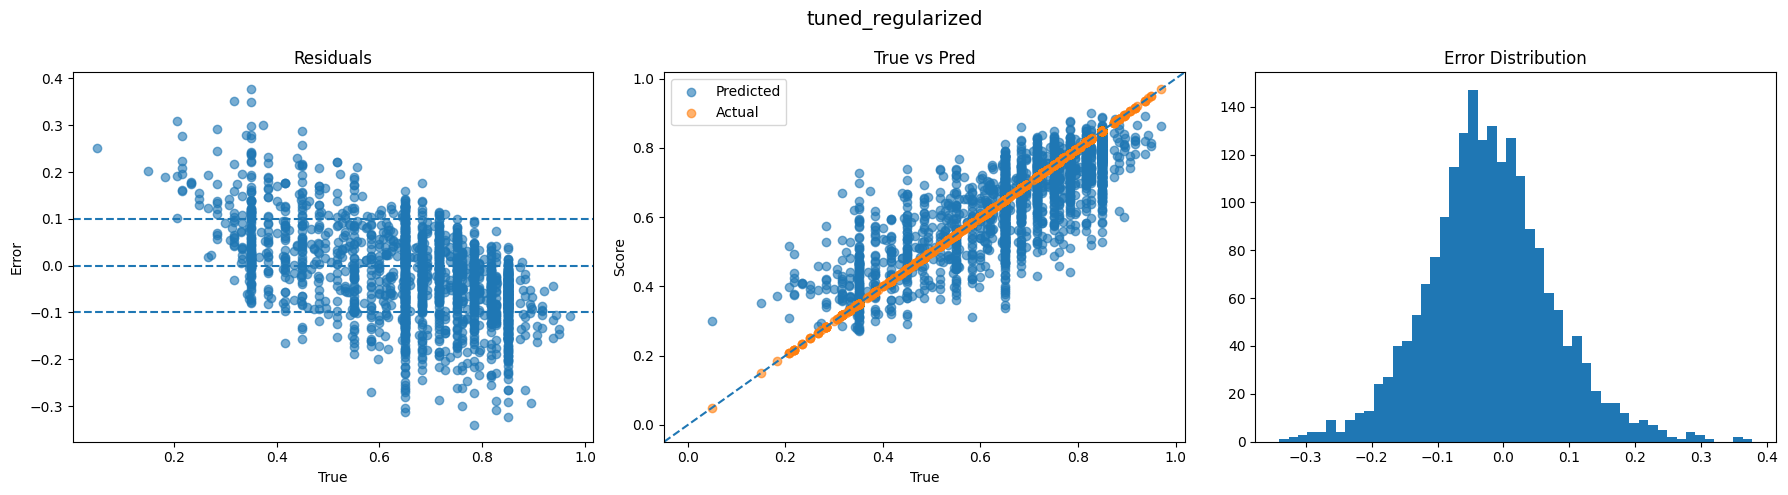


tuned_regularized
MAE: 0.0762
RMSE: 0.0980
Pearson: 0.8071
Spearman: 0.7877
Accuracy (%): 71.9500


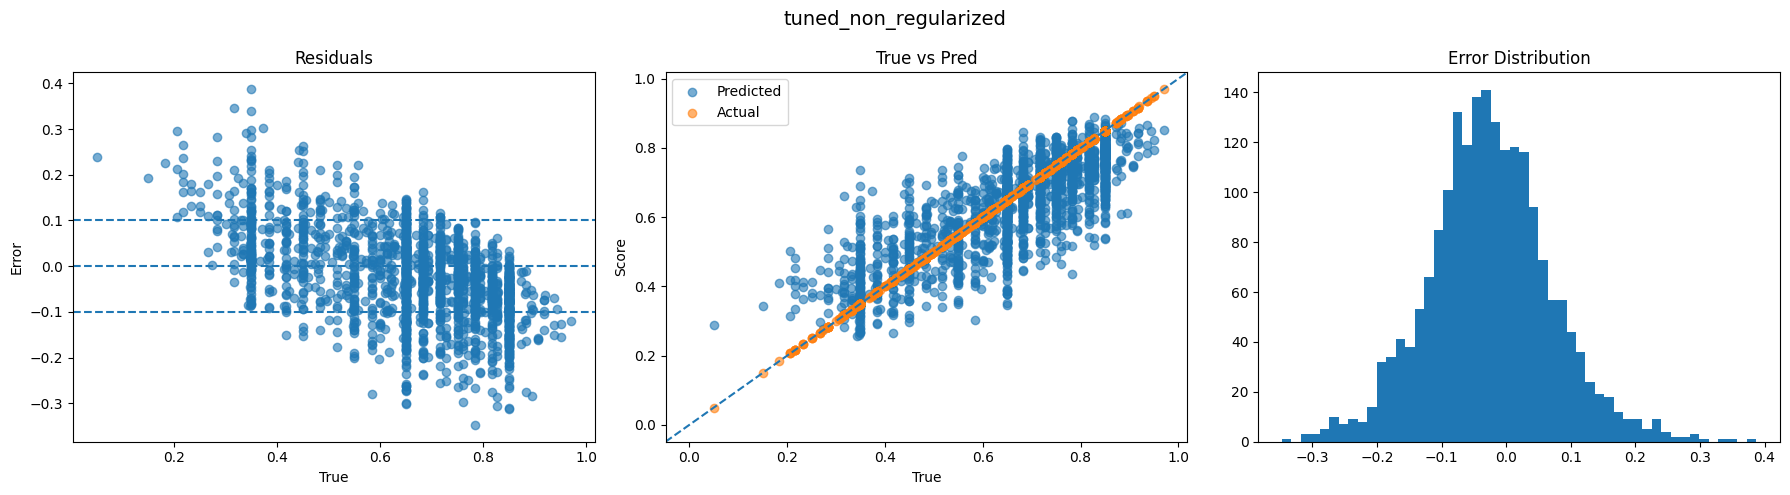


tuned_non_regularized
MAE: 0.0776
RMSE: 0.0993
Pearson: 0.8056
Spearman: 0.7840
Accuracy (%): 71.6500


In [3]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, f1_score, classification_report, mean_absolute_error, mean_squared_error
from sentence_transformers import SentenceTransformer, util
from scipy.stats import pearsonr, spearmanr


def clean_text(x):
    if pd.isna(x):
        return x
    x = str(x)
    x = re.sub(r'[\r\n]+', ' ', x)      # remove new lines / carriage returns
    x = re.sub(r'\s+', ' ', x)          # collapse multiple spaces
    x = x.strip()
    return x

def load_df_from_csv(f):
    df = pd.read_csv(f)
    df = df.map(clean_text).reset_index(drop=True)
    return df

def compute_scores(df, model):
    emb1 = model.encode(df["resume_text"].tolist(), convert_to_tensor=True)
    emb2 = model.encode(df["job_description_text"].tolist(), convert_to_tensor=True)
    return util.cos_sim(emb1, emb2).diagonal().cpu().numpy()

def evaluate_models(df, models, threshold=0.1):
    y_true = df["score"].values

    for name, model in models.items():
        y_pred = compute_scores(df, model)

        # ---- metrics (same logic as earlier, simplified) ----
        errors = y_pred - y_true
        within = np.abs(errors) <= threshold

        mse = mean_squared_error(y_true, y_pred)

        metrics = {
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mse),
            "Pearson": pearsonr(y_true, y_pred)[0],
            "Spearman": spearmanr(y_true, y_pred)[0],
            "Accuracy (%)": np.mean(within) * 100
        }

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Residual plot
        axes[0].scatter(y_true, errors, alpha=0.6)
        axes[0].axhline(0, linestyle="--")
        axes[0].axhline(threshold, linestyle="--")
        axes[0].axhline(-threshold, linestyle="--")
        axes[0].set_title("Residuals")
        axes[0].set_xlabel("True")
        axes[0].set_ylabel("Error")

        # 2D regression plot
        axes[1].scatter(y_true, y_pred, alpha=0.6, label="Predicted")
        axes[1].scatter(y_true, y_true, alpha=0.6, label="Actual")
        axes[1].axline((0, 0), slope=1, linestyle="--")
        axes[1].set_title("True vs Pred")
        axes[1].set_xlabel("True")
        axes[1].set_ylabel("Score")
        axes[1].legend()

        # Error distribution
        axes[2].hist(errors, bins=50)
        axes[2].set_title("Error Distribution")

        fig.suptitle(f"{name}", fontsize=14)
        plt.tight_layout()
        plt.show()

        # ---- print ----
        print(f"\n{name}")
        for k, v in metrics.items():
            print(f"{k}: {v:.4f}")

df = load_df_from_csv(DRIVE_PATH + "/dataset_5/jd_resume_score.csv").sample(2000)

candidate_cols = df.columns[[2, 4, 13, 14, 16]]
job_cols = df.columns[[28, 29, 30, 32, 33]]
score_col = df.columns[-1]

df["resume_text"]           = df[candidate_cols].fillna("").astype(str).agg(" ".join, axis=1)
df["job_description_text"]  = df[job_cols].fillna("").astype(str).agg(" ".join, axis=1)
df["score"]                 = df[score_col].astype(float)

df = df[["job_description_text", "resume_text", "score"]]
models = {
    "base_model": SentenceTransformer(BASE_MODEL),
    "tuned_regularized": SentenceTransformer(REGULARIZED_MODEL),
    "tuned_non_regularized": SentenceTransformer(NON_REGULARIZED_MODEL)
    }

evaluate_models(df, models)